In [1]:
import pandas as pd
import ast

comments = pd.read_csv('stemmed_all.csv')
data = comments.loc[:,['post_id','created_at','username','text']]
data_partial = data[(data['created_at'] > '2025-10-01') & (data['created_at'] < '2025-11-01')].copy()
data_partial['text'] = data_partial['text'].apply(ast.literal_eval)
data_partial

,post_id,created_at,username,text
10,DPiRgn6k9BI,2025-10-29 23:44:51 WIB,n_aiiniiii,"[maaf, gak, paham, min, harga, pasang, pdam, min]"
11,DPiRgn6k9BI,2025-10-30 05:38:39 WIB,raymundus_aryo,"[rame, nih, kdm, min]"
12,DPiRgn6k9BI,2025-10-31 04:47:10 WIB,opera8176,"[min, pdam, jalan, gresik, mati, gimana]"
13,DPiRgn6k9BI,2025-10-31 10:05:24 WIB,matokebenny,"[tugas, wilayah, ploso, timur, tolong, sp, kal..."
14,DPiRgn6k9BI,2025-10-31 10:06:07 WIB,matokebenny,"[kali, kirim, komplain, langsung, pecat, tugas]"
...,...,...,...,...
9760,C8jD4uDP9Bt,2025-10-16 01:37:13 WIB,mamaerisma30,"[pdampdamtolong, bikin, hidup, susahmasak, beg..."
9761,C8jD4uDP9Bt,2025-10-23 06:20:37 WIB,babyjotuhumena,"[pdam, hebat, kl, lambat, bayar, cepat num, pu..."
9762,C8jD4uDP9Bt,2025-10-25 14:55:57 WIB,melongrus,"[wilayah, dilendang, beso, kemaren, nyala, mat..."
9763,C8jD4uDP9Bt,2025-10-30 14:25:29 WIB,moh.asyari3112,"[wilayah, lampung, adu, nga, ya]"


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix
import numpy as np

data_partial['processed_text'] = data_partial['text'].apply(lambda tokens: " ".join(tokens))
data_partial = data_partial[data_partial['processed_text'].str.strip() != ""]
vectorizer = TfidfVectorizer(
    tokenizer=str.split,
    ngram_range=(1,1),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

vectors = vectorizer.fit_transform(data_partial['processed_text'])
feature_names = vectorizer.get_feature_names_out()
vectors_dense = vectors.toarray()
max_values_per_document = np.max(vectors_dense, axis=1)
thresholds = 0.5 * max_values_per_document
thresholds_reshaped = thresholds.reshape(-1, 1)
vectors_grounded = np.where(vectors_dense < thresholds_reshaped, 0, vectors_dense)
vectors_grounded_sparse = csr_matrix(vectors_grounded)

d:\Kuliah\PA\pdam-scraper\scrape_instagram\venv\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [4]:
vectors = vectorizer.fit_transform(data_partial['processed_text'])
feature_names = vectorizer.get_feature_names_out()
vectors_dense = vectors.toarray()

vectors_dense_old = vectors_dense.copy()
df_old = pd.DataFrame(vectors_dense_old, columns=feature_names)
df_old.insert(0, 'comment', data_partial['processed_text'].values)
df_old.to_csv("test_before_normalization.csv", index=False)
print(f"Old vector shape: {vectors_dense_old.shape}")

vectors_normalized = vectors_dense.copy()

for i in range(vectors_normalized.shape[0]):
    row = vectors_normalized[i]
    max_val = row.max()

    if max_val == 0:
        continue

    threshold = max_val / 2

    vectors_normalized[i] = np.where(row >= threshold, row, 0.0)

non_zero_cols = np.any(vectors_normalized != 0, axis=0)
vectors_normalized = vectors_normalized[:, non_zero_cols]
feature_names_normalized = feature_names[non_zero_cols]

print(f"New vector shape: {vectors_normalized.shape}")
print(f"Features removed: {vectors_dense.shape[1] - vectors_normalized.shape[1]}")

df_new = pd.DataFrame(vectors_normalized, columns=feature_names_normalized)
df_new.insert(0, 'comment', data_partial['processed_text'].values)
df_new.to_csv("test_after_normalization.csv", index=False)

print("Saved: tfidf_before_normalization.csv and tfidf_after_normalization.csv")

d:\Kuliah\PA\pdam-scraper\scrape_instagram\venv\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Old vector shape: (1159, 713)
New vector shape: (1159, 713)
Features removed: 0
Saved: tfidf_before_normalization.csv and tfidf_after_normalization.csv


Linkage shape: (1158, 4), Samples: 1159
max_k 100

Optimal K Results:
• WCSS Curvature: 95
• Silhouette Max: 2


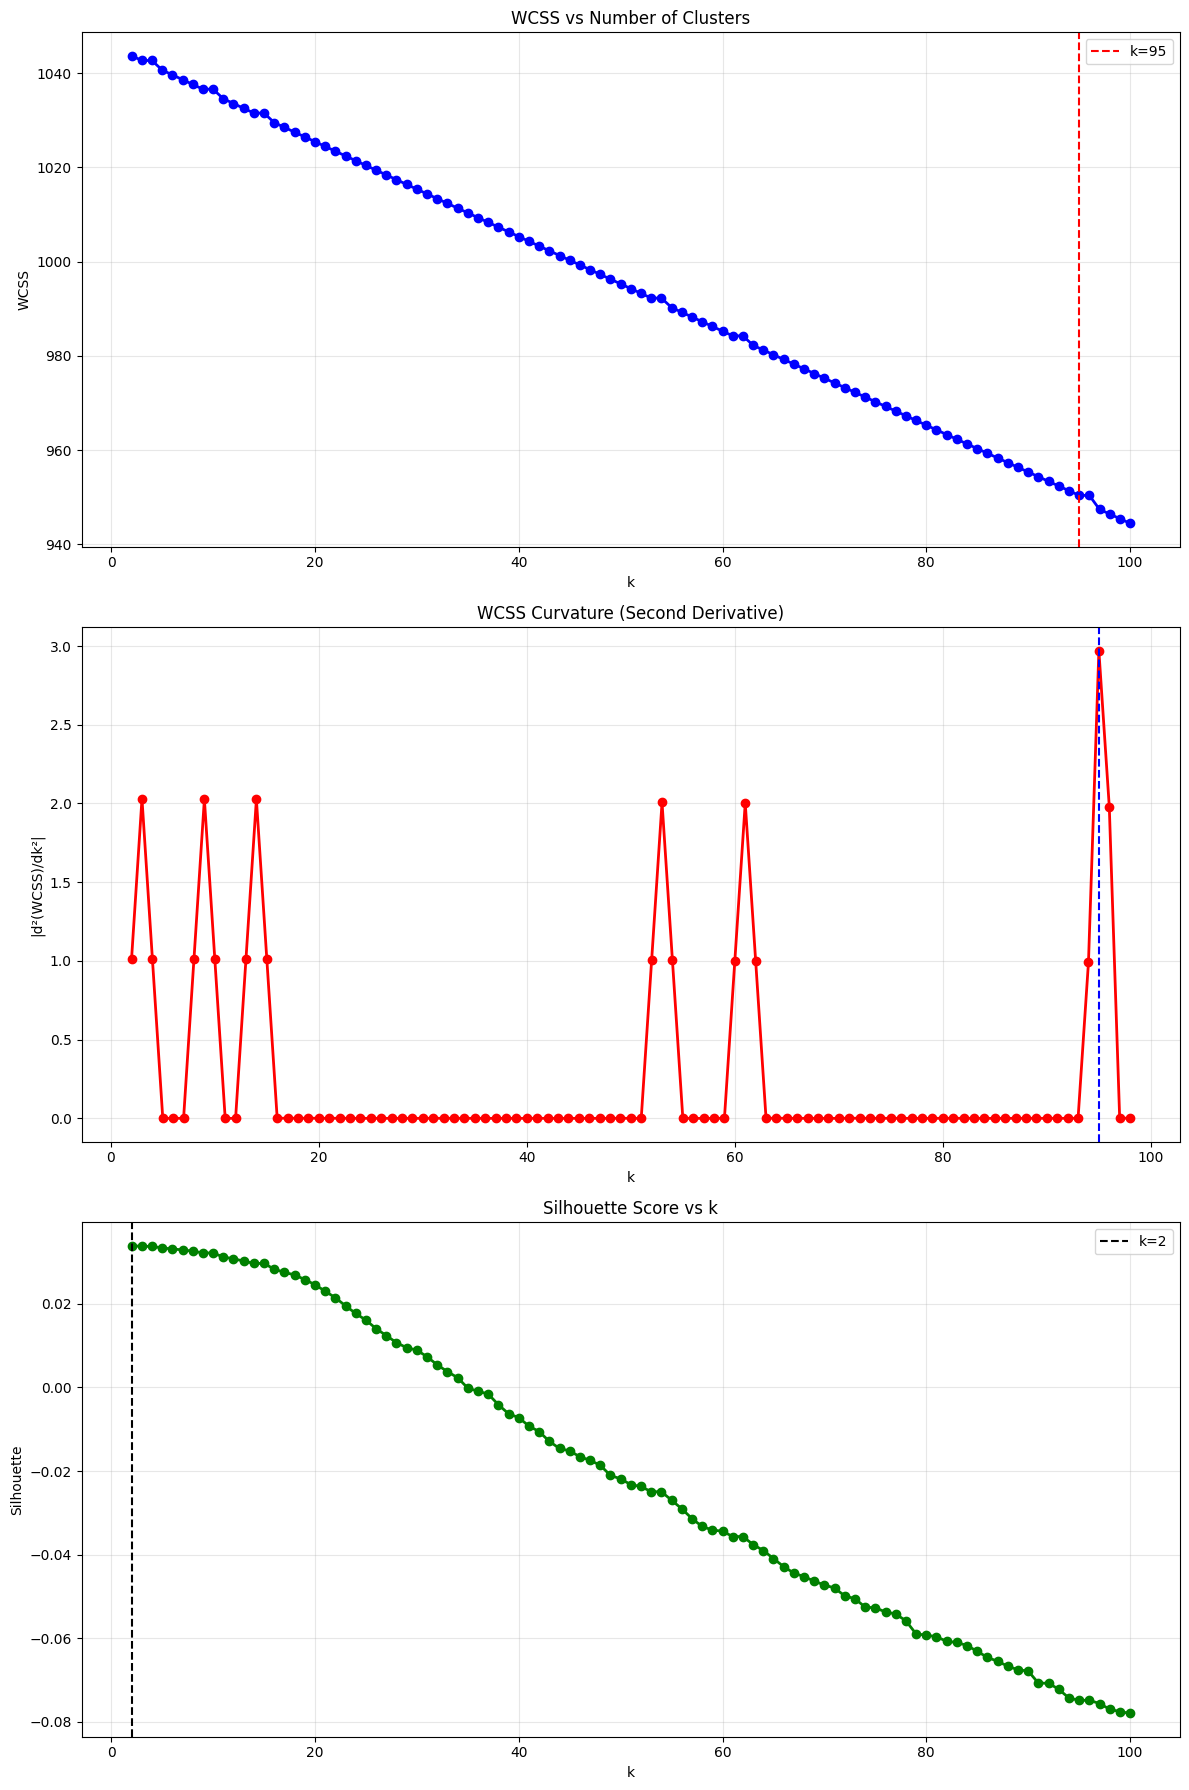

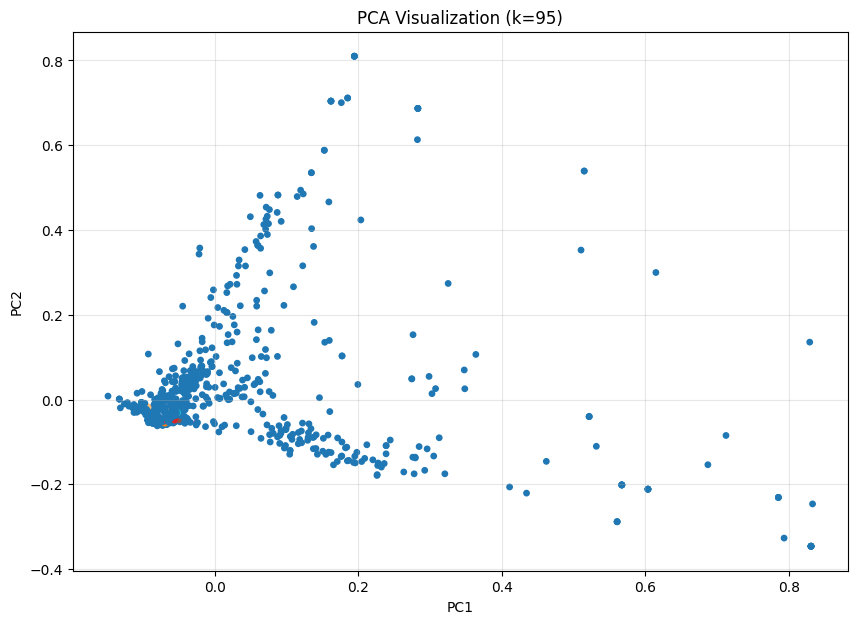

In [3]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
Z = linkage(vectors_dense, method='centroid', metric='euclidean')
Z_grounded = linkage(vectors_grounded, method='centroid', metric='euclidean')
n_samples = vectors_dense.shape[0]
print(f"Linkage shape: {Z.shape}, Samples: {n_samples}")

MIN_SAMPLES_PER_CLUSTER = 20
max_k = 100
print("max_k", max_k)
k_list = list(range(max_k, 1, -1))

wcss, sil = [], []

for k in k_list:
    labels = fcluster(Z_grounded, t=k, criterion='maxclust')
    
    total_var = 0.0
    for cid in np.unique(labels):
        pts = vectors_grounded[labels == cid]
        if pts.shape[0] <= 1:
            continue
        cent = pts.mean(axis=0)
        total_var += np.sum(np.linalg.norm(pts - cent, axis=1)**2)
    wcss.append(total_var)
    # Sil
    if len(np.unique(labels)) >= 2:
        sc = silhouette_score(vectors_grounded, labels, metric='euclidean')
    else:
        sc = np.nan
    sil.append(sc)

wcss, sil = np.array(wcss), np.array(sil)

# cobacob dl
# WCSS Curve
first = np.diff(wcss)
second = np.diff(first)
idx_curv = np.nanargmax(np.abs(second))
k_curv = k_list[idx_curv + 2]

# Silhouette Max
valid_idx = np.where(~np.isnan(sil))[0]
k_sil = k_list[valid_idx[np.nanargmax(sil[valid_idx])]] if len(valid_idx) else None

print(f"\nOptimal K Results:")
print(f"• WCSS Curvature: {k_curv}")
print(f"• Silhouette Max: {k_sil}")


fig, axes = plt.subplots(3, 1, figsize=(12, 18))
axes[0].plot(k_list, wcss, 'bo-', linewidth=2)
axes[0].axvline(k_curv, color='red', linestyle='--', label=f"k={k_curv}")
axes[0].set_title("WCSS vs Number of Clusters")
axes[0].set_xlabel("k"); axes[0].set_ylabel("WCSS")
axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(k_list[2:], np.abs(second), 'ro-', linewidth=2)
axes[1].axvline(k_curv, color='blue', linestyle='--')
axes[1].set_title("WCSS Curvature (Second Derivative)")
axes[1].set_xlabel("k"); axes[1].set_ylabel("|d²(WCSS)/dk²|")
axes[1].grid(alpha=0.3)

axes[2].plot(k_list, sil, 'go-', linewidth=2)
if k_sil:
    axes[2].axvline(k_sil, color='black', linestyle='--', label=f"k={k_sil}")
axes[2].set_title("Silhouette Score vs k")
axes[2].set_xlabel("k"); axes[2].set_ylabel("Silhouette")
axes[2].grid(alpha=0.3); axes[2].legend()

plt.tight_layout()
plt.show()

# PCA Vis
k_optimal = k_curv
labels_opt = fcluster(Z_grounded, t=k_optimal, criterion='maxclust')

pca = PCA(n_components=2)
vec2d = pca.fit_transform(vectors_grounded)

plt.figure(figsize=(10, 7))
plt.scatter(vec2d[:,0], vec2d[:,1], c=labels_opt, cmap='tab20', s=15)
plt.title(f"PCA Visualization (k={k_optimal})")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.show()

Linkage shape: (1158, 4), Samples: 1159
max_k 100

Optimal K Results:


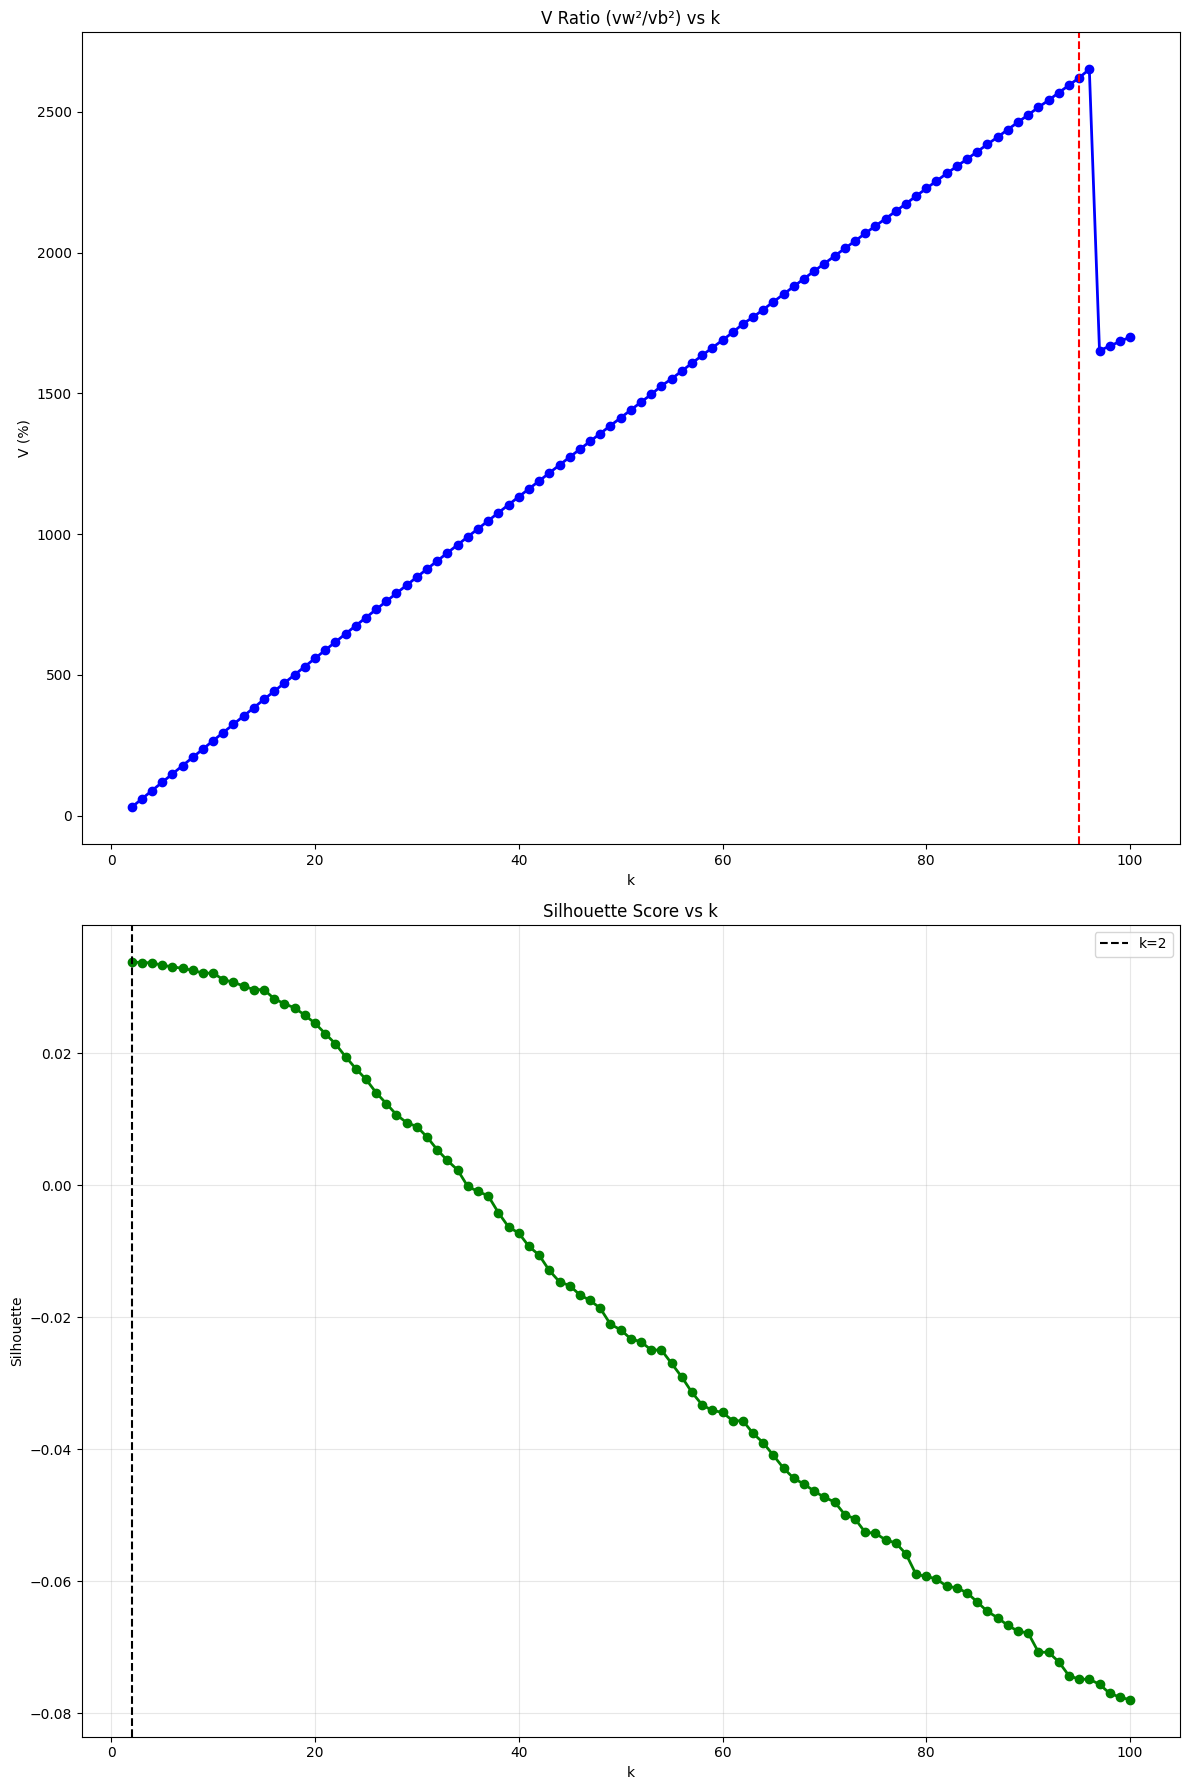

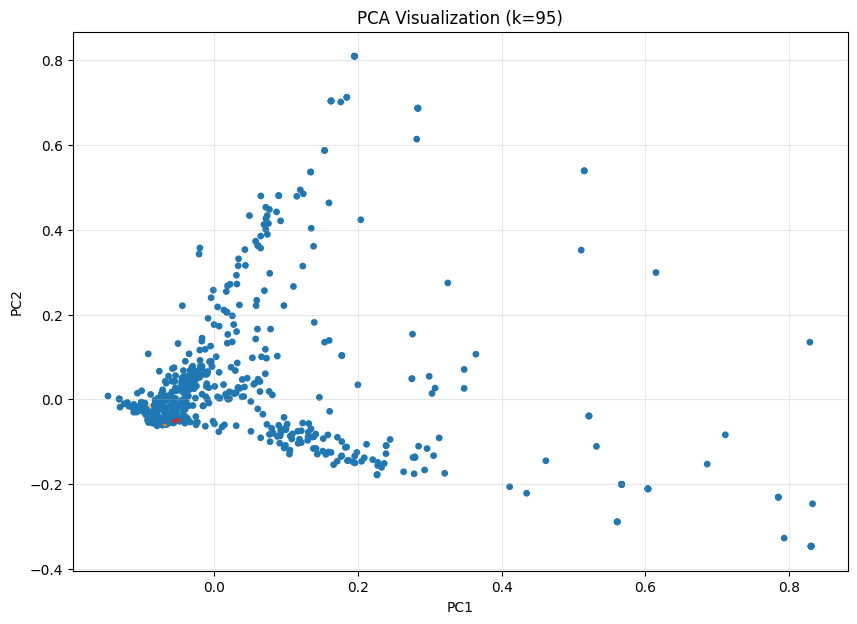

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from sklearn.decomposition import PCA
Z = linkage(vectors_dense, method='centroid', metric='euclidean')
Z_grounded = linkage(vectors_grounded, method='centroid', metric='euclidean')
n_samples = vectors_dense.shape[0]
print(f"Linkage shape: {Z.shape}, Samples: {n_samples}")

MIN_SAMPLES_PER_CLUSTER = 20
max_k = 100
print("max_k", max_k)
k_list = list(range(max_k, 1, -1))

# wcss, sil = [], []
sil = []

# for k in k_list:
#     labels = fcluster(Z_grounded, t=k, criterion='maxclust')
    
#     total_var = 0.0
#     for cid in np.unique(labels):
#         pts = vectors_grounded[labels == cid]
#         if pts.shape[0] <= 1:
#             continue
#         cent = pts.mean(axis=0)
#         total_var += np.sum(np.linalg.norm(pts - cent, axis=1)**2)
#     wcss.append(total_var)
    
#     # Sil
#     if len(np.unique(labels)) >= 2:
#         sc = silhouette_score(vectors_grounded, labels, metric='euclidean')
#     else:
#         sc = np.nan
#     sil.append(sc)

# wcss, sil = np.array(wcss), np.array(sil)

    # # variance of cluster/delta
    # # δp^2 = (i/(n-1)) (∑n,i=1) (xi-xp)^2
vw_list = []
vb_list = []
v_ratio = []

N = vectors_grounded.shape[0]
grand_mean = vectors_grounded.mean(axis=0)

for k in k_list:
    labels = fcluster(Z_grounded, t=k, criterion='maxclust')
    unique_clusters = np.unique(labels)
    
    delta_within = 0.0
    delta_between = 0.0
    
    for cid in unique_clusters:
        pts = vectors_grounded[labels == cid]
        ni = pts.shape[0]
        
        if ni <= 1:
            continue
        
        centroid = pts.mean(axis=0)
        
        # δp^2
        delta_sq = np.sum(np.linalg.norm(pts - centroid, axis=1)**2) / (ni - 1)
        
        # accum within
        delta_within += (ni - 1) * delta_sq
        
        # betw
        delta_between += ni * np.linalg.norm(centroid - grand_mean)**2
    
    # vw^2 & vb^2
    if (N - k) > 0:
        vw2 = delta_within / (N - k)
    else:
        vw2 = np.nan
        
    if (k - 1) > 0:
        vb2 = delta_between / (k - 1)
    else:
        vb2 = np.nan
    
    vw_list.append(vw2)
    vb_list.append(vb2)
    
    if vb2 > 0:
        v_ratio.append((vw2 / vb2) * 100)
    else:
        v_ratio.append(np.nan)

    if len(unique_clusters) >= 2:
        sc = silhouette_score(vectors_grounded, labels, metric='euclidean')
    else:
        sc = np.nan
        
    sil.append(sc)

vw_list = np.array(vw_list)
vb_list = np.array(vb_list)
v_ratio = np.array(v_ratio)

first = np.diff(v_ratio)
second = np.diff(first)
idx_curv = np.nanargmax(np.abs(second))
k_curv = k_list[idx_curv + 2]

# v_smooth = gaussian_filter1d(v_ratio, sigma=2)

# valley_indices, _ = find_peaks(-v_smooth)

# if len(valley_indices) > 0:
#     best_idx = valley_indices[np.argmin(v_smooth[valley_indices])]
#     k_valley = k_list[best_idx]
# else:
#     k_valley = None

# Silhouette Max
sil = np.array(sil)
valid_idx = np.where(~np.isnan(sil))[0]
k_sil = k_list[valid_idx[np.nanargmax(sil[valid_idx])]] if len(valid_idx) else None

print(f"\nOptimal K Results:")

fig, axes = plt.subplots(2, 1, figsize=(12, 18))
axes[0].plot(k_list, v_ratio, 'bo-', linewidth=2)
axes[0].axvline(k_curv, color='red', linestyle='--', label=f"k={k_curv}")
axes[0].set_title("V Ratio (vw²/vb²) vs k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("V (%)")
# axes[0].plot(k_list, v_ratio, color='lightgray', label='Raw')
# axes[0].plot(k_list, v_smooth, 'b-', linewidth=2, label='Smoothed')

# if k_valley:
#     axes[0].axvline(k_valley, color='red', linestyle='--',
#                     label=f"Valley k={k_valley}")

# axes[0].set_title("V Ratio (vw²/vb²) vs k")
# axes[0].set_xlabel("k")
# axes[0].set_ylabel("V (%)")
# axes[0].legend()

axes[1].plot(k_list, sil, 'go-', linewidth=2)
if k_sil:
    axes[1].axvline(k_sil, color='black', linestyle='--', label=f"k={k_sil}")
axes[1].set_title("Silhouette Score vs k")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.show()

k_optimal = k_curv
labels_opt = fcluster(Z_grounded, t=k_optimal, criterion='maxclust')

pca = PCA(n_components=2)
vec2d = pca.fit_transform(vectors_grounded)

plt.figure(figsize=(10, 7))
plt.scatter(vec2d[:,0], vec2d[:,1], c=labels_opt, cmap='tab20', s=15)
plt.title(f"PCA Visualization (k={k_optimal})")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.show()

1. δp^2 = (1/(n-1)) ∑_{i=1..n} (xi - x̄p)^2
2. vw^2 = (1/(N-k)) ∑_{i=1..k} (ni - 1)δi^2
3. vb^2 = (1/(k-1)) ∑_{i=1..k} (ni(x̄i - x̄)^2
4. V = (vw^2)/(vb^2) * 100%
5. (V_{i-1} ≥ V_i) ∩ (V_{i+1} > V_i)

Linkage shape: (1158, 4), Samples: 1159
max_k 100

Optimal K Results:


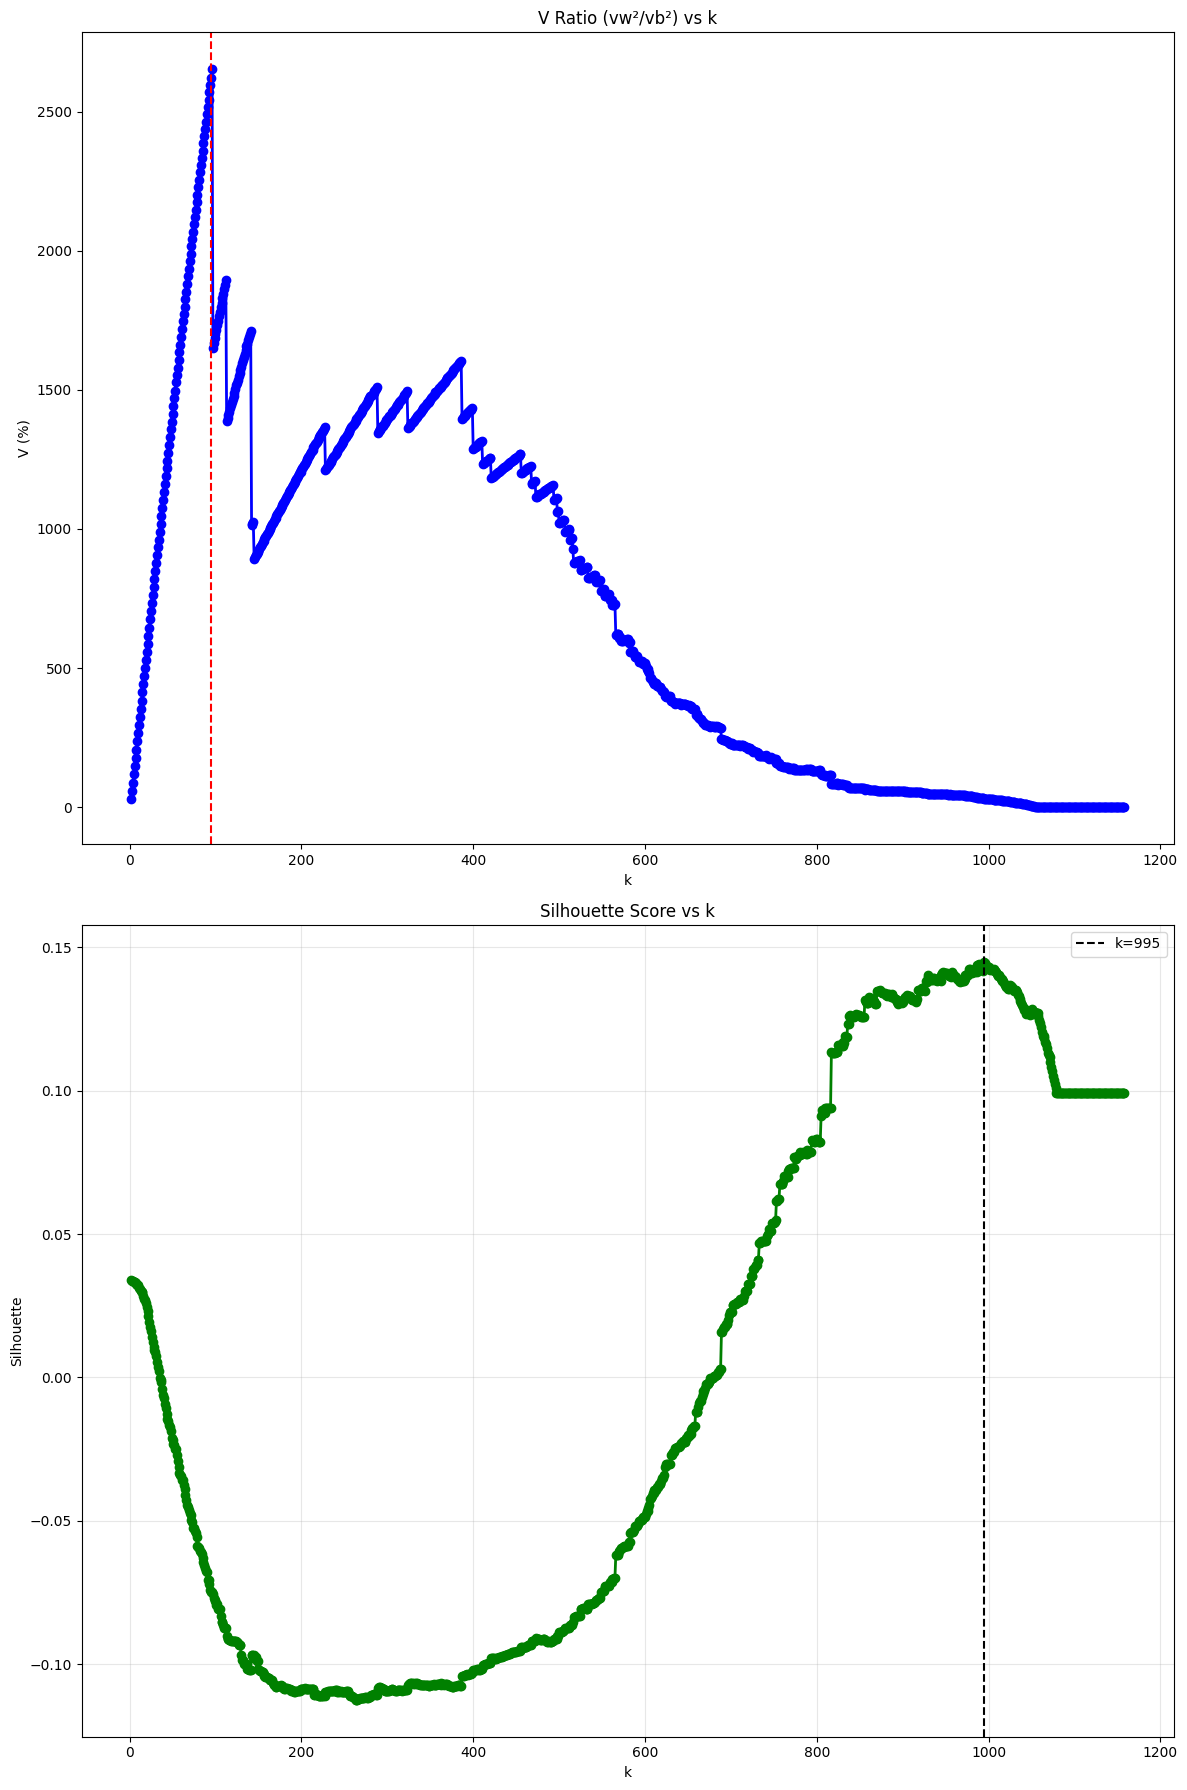

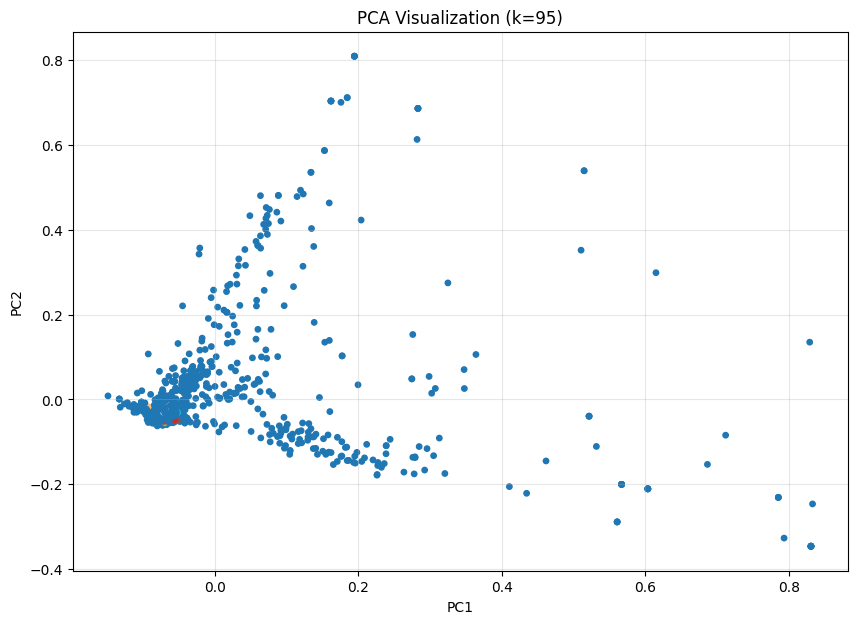

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from sklearn.decomposition import PCA
Z = linkage(vectors_dense, method='centroid', metric='euclidean')
Z_grounded = linkage(vectors_grounded, method='centroid', metric='euclidean')
N = vectors_grounded.shape[0]
print(f"Linkage shape: {Z.shape}, Samples: {N}")

MIN_SAMPLES_PER_CLUSTER = 20
max_k = 100
print("max_k", max_k)
k_list = list(range(N, 1, -1))

sil = []

vw_list = []
vb_list = []
v_ratio = []
valley = []

N = vectors_grounded.shape[0]
grand_mean = vectors_grounded.mean(axis=0)


for k in k_list:
    labels = fcluster(Z_grounded, t=k, criterion='maxclust')
    unique_clusters = np.unique(labels)
    
    delta_within = 0.0
    delta_between = 0.0
    
    for cid in unique_clusters:
        pts = vectors_grounded[labels == cid]
        ni = pts.shape[0]
        
        if ni <= 1:
            continue
        
        centroid = pts.mean(axis=0)
        
        # δp^2
        delta_sq = np.sum(np.linalg.norm(pts - centroid, axis=1)**2) / (ni - 1)
        
        # accum within
        delta_within += (ni - 1) * delta_sq
        
        # betw
        delta_between += ni * np.linalg.norm(centroid - grand_mean)**2
    
    # vw^2 & vb^2
    if (N - k) > 0:
        vw2 = delta_within / (N - k)
    else:
        vw2 = np.nan
        
    if (k - 1) > 0:
        vb2 = delta_between / (k - 1)
    else:
        vb2 = np.nan
    
    vw_list.append(vw2)
    vb_list.append(vb2)
    
    if vb2 > 0:
        v_ratio.append((vw2 / vb2) * 100)
    else:
        v_ratio.append(np.nan)

    if len(unique_clusters) >= 2:
        sc = silhouette_score(vectors_grounded, labels, metric='euclidean')
    else:
        sc = np.nan
        
    sil.append(sc)

vw_list = np.array(vw_list)
vb_list = np.array(vb_list)
v_ratio = np.array(v_ratio)

# vt is found when (V[i-1] >= V[i]) ∩ (V[i+1] > V[i])

first = np.diff(v_ratio)
second = np.diff(first)
idx_curv = np.nanargmax(np.abs(second))
k_curv = k_list[idx_curv + 2]

# Sil
sil = np.array(sil)
valid_idx = np.where(~np.isnan(sil))[0]
k_sil = k_list[valid_idx[np.nanargmax(sil[valid_idx])]] if len(valid_idx) else None

print(f"\nOptimal K Results:")

fig, axes = plt.subplots(2, 1, figsize=(12, 18))
axes[0].plot(k_list, v_ratio, 'bo-', linewidth=2)
axes[0].axvline(k_curv, color='red', linestyle='--', label=f"k={k_curv}")
axes[0].set_title("V Ratio (vw²/vb²) vs k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("V (%)")

# fig for valley tracing

axes[1].plot(k_list, sil, 'go-', linewidth=2)
if k_sil:
    axes[1].axvline(k_sil, color='black', linestyle='--', label=f"k={k_sil}")
axes[1].set_title("Silhouette Score vs k")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.show()

# PCA Vis
k_optimal = k_curv
labels_opt = fcluster(Z_grounded, t=k_optimal, criterion='maxclust')

pca = PCA(n_components=2)
vec2d = pca.fit_transform(vectors_grounded)

plt.figure(figsize=(10, 7))
plt.scatter(vec2d[:,0], vec2d[:,1], c=labels_opt, cmap='tab20', s=15)
plt.title(f"PCA Visualization (k={k_optimal})")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.show()

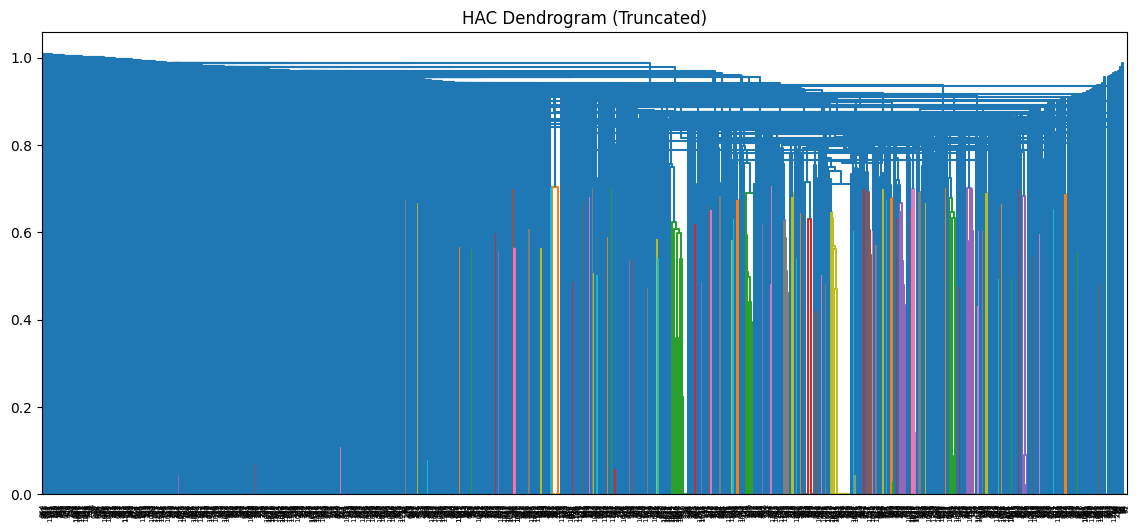

In [ ]:
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(14,6))
dendrogram(Z_grounded, p=5) # truncate_mode='level'
plt.title("HAC Dendrogram (Truncated)")
plt.show()

In [8]:
def simple_keyword(tfidf_matrix, feature_names, labels, k):
    cluster_keywords = {}
    
    for cluster_id in range(1, k + 1):
        indices = np.where(labels == cluster_id)[0]
        
        if len(indices) == 0:
            cluster_keywords[cluster_id] = []
            continue

        cluster_data = tfidf_matrix[indices]

        if hasattr(cluster_data, 'toarray'):
            cluster_data = cluster_data.toarray()

        cluster_mean = cluster_data.mean(axis=0)
        threshold = cluster_mean.max() / 2
        above_threshold = np.where(cluster_mean > threshold)[0]
        sorted_idx = above_threshold[np.argsort(-cluster_mean[above_threshold])]
        
        keywords = [(feature_names[i], cluster_mean[i]) for i in sorted_idx]
        cluster_keywords[cluster_id] = keywords
    
    return cluster_keywords

keywords = simple_keyword(vectors_dense, feature_names, labels_opt, k_optimal)

for cluster_id in range(1, min(k_optimal + 1, n_samples)):
    if cluster_id in keywords and keywords[cluster_id]:
        print(f"\nCluster {cluster_id}:")
        for word, score in keywords[cluster_id][:10]:
            print(f"  {word}: {score:.3f}")


Cluster 1:
  wahh: 1.000

Cluster 2:
  air: 0.090
  mati: 0.087
  min: 0.066
  nyala: 0.058

Cluster 3:
  balas: 0.687
  dm: 0.601
  ga: 0.409

Cluster 4:
  tau: 0.558
  kalo: 0.499
  barat: 0.490
  benowo: 0.447

Cluster 5:
  promo: 0.657
  sampek: 0.488
  tanggal: 0.430
  info: 0.382

Cluster 6:
  diskon: 0.397
  ben: 0.381
  bingung: 0.358
  rugi: 0.349
  seng: 0.335
  g: 0.292
  tagih: 0.279
  warga: 0.259
  banyu: 0.239
  kerja: 0.220

Cluster 7:
  tau: 0.550
  sekali: 0.497
  sama: 0.492
  karah: 0.456

Cluster 8:
  whatsapp: 0.558
  via: 0.511
  adu: 0.453
  num: 0.359
  ga: 0.304

Cluster 9:
  isi: 0.656
  selamat: 0.596
  rumah: 0.464

Cluster 10:
  bareng: 0.563
  jelas: 0.563
  bocor: 0.374
  pipa: 0.362
  tolong: 0.306

Cluster 11:
  kandang: 0.597
  kena: 0.485
  dampak: 0.458
  admin: 0.445

Cluster 12:
  lak: 0.535
  tiap: 0.535
  hari: 0.389
  admin: 0.378
  pbi: 0.366

Cluster 13:
  smp: 0.439
  tanggap: 0.407
  instagram: 0.399
  komen: 0.399
  makasih: 0.379
  kalo: